<a href="https://colab.research.google.com/github/NadiaTeta/group1/blob/main/notebooks/05_layer_norm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== SHARED SETUP CELL (the same in every group member's notebook) =====
!pip install -q transformers

import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(42)   # so random results are the same for everyone
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load the already-trained GPT-2 (small version) from Hugging Face
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    output_attentions=True,         # lets us look at attention weights
    output_hidden_states=True,      # lets us look at the numbers after each layer
    attn_implementation="eager",    # needed so attention weights can be returned
).to(device)
model.eval()                        # we're exploring, not training

print("Device:", device)
print(f"GPT-2 loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} million parameters")

# shared example sentences: the same meaning in English and Kinyarwanda
english = "The people of Kicukiro say they have not had water for three days."
kinyarwanda = "Abaturage bo mu Kicukiro bavuga ko bamaze iminsi itatu nta mazi bafite."

for name, sentence in [("English", english), ("Kinyarwanda", kinyarwanda)]:
    tokens = tokenizer.tokenize(sentence)
    print(f"\n{name}: {len(tokens)} tokens")
    print(tokens)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device: cpu
GPT-2 loaded: 124 million parameters

English: 17 tokens
['The', 'Ġpeople', 'Ġof', 'ĠK', 'ic', 'uk', 'iro', 'Ġsay', 'Ġthey', 'Ġhave', 'Ġnot', 'Ġhad', 'Ġwater', 'Ġfor', 'Ġthree', 'Ġdays', '.']

Kinyarwanda: 29 tokens
['Ab', 'atur', 'age', 'Ġbo', 'Ġmu', 'ĠK', 'ic', 'uk', 'iro', 'Ġb', 'av', 'uga', 'Ġko', 'Ġb', 'am', 'aze', 'Ġim', 'ins', 'i', 'Ġit', 'atu', 'Ġn', 'ta', 'Ġm', 'azi', 'Ġb', 'af', 'ite', '.']


In [2]:
# Cell 2: find the layer norms inside GPT-2
print(model.transformer.h[0])     # what one block looks like

ln_names = [name for name, m in model.named_modules() if isinstance(m, torch.nn.LayerNorm)]
print("\nNumber of layer norms in GPT-2:", len(ln_names))
print("First ones:", ln_names[:3])
print("Last ones:", ln_names[-2:])

ln = model.transformer.h[0].ln_1
print("\nLearned scale (weight) shape:", ln.weight.shape)
print("Learned shift (bias) shape:", ln.bias.shape)

GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

Number of layer norms in GPT-2: 25
First ones: ['transformer.h.0.ln_1', 'transformer.h.0.ln_2', 'transformer.h.1.ln_1']
Last ones: ['transformer.h.11.ln_2', 'transformer.ln_f']

Learned scale (weight) shape: torch.Size([768])
Learned shift (bias) shape: torch.Size([768])


In [3]:
# Cell 3: what layer norm does to one token's numbers
inputs = tokenizer(english, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**inputs)

x = out.hidden_states[3][0]           # numbers entering block 3 (one row per token)
ln = model.transformer.h[3].ln_1      # the layer norm at the start of block 3
with torch.no_grad():
    y = ln(x)

tok_i = 5                             # look at the 6th token of the sentence
token = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])[tok_i]
print(f"Token: {token!r}\n")

print(f"BEFORE layer norm: average {x[tok_i].mean():.3f}, spread (std) {x[tok_i].std():.3f}, "
      f"smallest {x[tok_i].min():.2f}, largest {x[tok_i].max():.2f}")
print(f"AFTER layer norm:  average {y[tok_i].mean():.3f}, spread (std) {y[tok_i].std():.3f}, "
      f"smallest {y[tok_i].min():.2f}, largest {y[tok_i].max():.2f}")

# the core step done by hand: centre on 0, then scale to a spread of 1
manual = (x[tok_i] - x[tok_i].mean()) / torch.sqrt(x[tok_i].var(unbiased=False) + 1e-5)
print(f"\nBy hand (before the learned scale and shift): average {manual.mean():.3f}, spread {manual.std():.3f}")

Token: 'uk'

BEFORE layer norm: average -0.010, spread (std) 2.192, smallest -22.44, largest 17.83
AFTER layer norm:  average 0.006, spread (std) 0.350, smallest -5.50, largest 4.52

By hand (before the learned scale and shift): average -0.000, spread 1.001


Layer | size before LN | size after LN
    0 |            5.1 |           2.9
    1 |           54.5 |           4.1
    2 |           56.2 |           7.7
    3 |           60.9 |           9.5
    4 |           66.6 |           8.9
    5 |           72.4 |          10.6
    6 |           78.8 |           9.9
    7 |           89.2 |           9.9
    8 |          104.6 |           9.2
    9 |          126.3 |           8.9
   10 |          159.7 |           8.3
   11 |          245.6 |           7.7


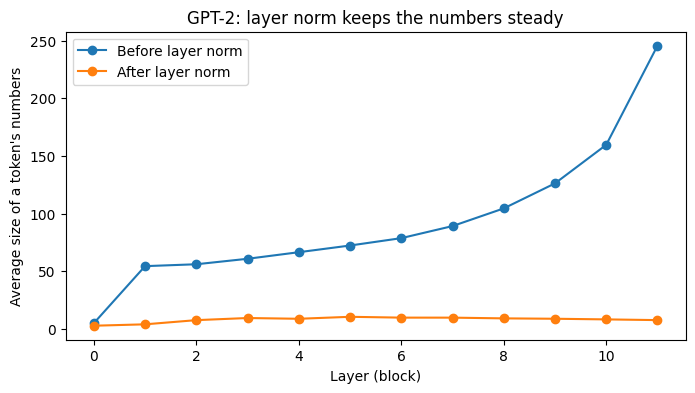


First token's size before layer norm, per layer: [10, 133, 636, 2564, 2748, 2897, 2991, 3046, 3080, 3101, 3111, 3112]


In [4]:
# Cell 4: MAIN EXPERIMENT - the size of the numbers through all 12 layers
import matplotlib.pyplot as plt

before, after, first_token = [], [], []

def make_hook():
    def hook(module, inp, outp):
        b = inp[0][0]     # numbers going INTO layer norm
        a = outp[0]       # numbers coming OUT of layer norm
        before.append(b[1:].norm(dim=-1).mean().item())   # average size, skipping the first token
        after.append(a[1:].norm(dim=-1).mean().item())
        first_token.append(b[0].norm().item())             # the first token, measured separately
    return hook

hooks = [block.ln_1.register_forward_hook(make_hook()) for block in model.transformer.h]
with torch.no_grad():
    model(**inputs)
for h in hooks:
    h.remove()

print("Layer | size before LN | size after LN")
for i in range(12):
    print(f"{i:5} | {before[i]:14.1f} | {after[i]:13.1f}")

plt.figure(figsize=(8, 4))
plt.plot(range(12), before, marker='o', label='Before layer norm')
plt.plot(range(12), after, marker='o', label='After layer norm')
plt.xlabel("Layer (block)")
plt.ylabel("Average size of a token's numbers")
plt.title("GPT-2: layer norm keeps the numbers steady")
plt.legend()
plt.show()

print("\nFirst token's size before layer norm, per layer:", [round(v) for v in first_token])

In [5]:
# Cell 5: EXTRA EXPERIMENT - what happens if we remove the layer norms?
import copy

def text_loss(m, sentence):
    enc = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        return m(**enc, labels=enc["input_ids"]).loss.item()

def continue_text(m, prompt, n=20):
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = m.generate(**enc, max_new_tokens=n, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0])

no_ln = copy.deepcopy(model)              # a copy, so the original GPT-2 stays untouched
for block in no_ln.transformer.h:
    block.ln_1 = torch.nn.Identity()      # Identity = "do nothing", i.e. layer norm removed
    block.ln_2 = torch.nn.Identity()

print(f"Loss WITH layer norm:    {text_loss(model, english):.2f}")
print(f"Loss WITHOUT layer norm: {text_loss(no_ln, english):.2f}")

prompt = "The people of Kicukiro say"
print("\nWITH layer norm:   ", continue_text(model, prompt))
print("WITHOUT layer norm:", continue_text(no_ln, prompt))

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Loss WITH layer norm:    4.46
Loss WITHOUT layer norm: nan

WITH layer norm:    The people of Kicukiro say that the city is a place of peace and harmony.

"We are not afraid of the
WITHOUT layer norm: The people of Kicukiro say!!!!!!!!!!!!!!!!!!!!
